### Лабораторная работа №4. Классификация изображений
Цель: Научиться классифицировать изображения.

## Введение

Свёрточные нейронные сети представляют собой класс feedforward-нейронных сетей, специально адаптированный для эффективной обработки данных, обладающих **сеточной топологией** (главным образом — многоканальных изображений).  

Основная идея CNN заключается в использовании **локальности связей** и **разделения весов** (parameter sharing), что позволяет радикально сократить количество обучаемых параметров по сравнению с полносвязными сетями при сохранении (и даже улучшении) способности к обобщению на задачах компьютерного зрения.

Архитектурные решения CNN вдохновлены принципами организации зрительной коры млекопитающих (в частности, работами Хьюбела и Визеля, 1959–1962), в которой обнаружены **простые** и **сложные клетки**, реагирующие на локальные ориентированные стимулы и обладающие свойством инвариантности к небольшим сдвигам.

## Основные принципы и преимущества

| Принцип                  | Описание                                                                 | Эффект на обучение и производительность                     |
|--------------------------|--------------------------------------------------------------------------|---------------------------------------------------------------------|
| Локальная связность      | Каждый нейрон связан лишь с небольшой областью предыдущего слоя         | Снижение числа параметров, учёт пространственной структуры         |
| Разделение весов         | Один и тот же фильтр применяется ко всей карте признаков                 | Эквивариантность к трансляции, резкое уменьшение параметров        |
| Инвариантность/эквивариантность | Свойства к малым трансляциям, поворотам, масштабированию (частично)     | Улучшение обобщающей способности                                   |
| Иерархическое извлечение признаков | Низкоуровневые → среднеуровневые → высокоуровневые признаки            | Автоматическое обучение представлений вместо ручной инженерии      |

## Основные структурные блоки CNN

Типичная архитектура CNN состоит из чередующихся слоёв следующих типов:

1. **Сверточный слой (Convolutional layer, CONV)**  
2. **Нелинейность (обычно ReLU)**  
3. **Слой пространственного объединения (Pooling layer, POOL)**  
4. **Нормализация (Batch Normalization, опционально)**  
5. **Полносвязные слои (Fully Connected, FC / Dense)** — в конце архитектуры

### 1. Сверточный слой

**Математическая операция свёртки**:

Для одного входного канала и одного фильтра:

$$
(I * K)_{i,j} = \sum_{m}\sum_{n} I_{i+m,j+n} \cdot K_{m,n}
$$

Для многоканального входа (C_in каналов) и одного выходного фильтра:

$$
Z_{i,j,k} = \sum_{c=1}^{C_{in}} \sum_{m}\sum_{n} X_{i+m,j+n,c} \cdot W_{m,n,c,k} + b_k
$$

**Гиперпараметры свёрточного слоя**:

- Размер ядра (kernel size) — обычно 3×3, 5×5, 1×1  
- Шаг (stride) — чаще всего 1 или 2  
- Нулевое заполнение (padding) — valid / same  
- Количество фильтров (число выходных каналов) — C_out

### 2. Функции активации

Наиболее часто используется **ReLU** (Rectified Linear Unit):

$$
f(x) = \max(0, x)
$$

Варианты: Leaky ReLU, PReLU, ELU, Swish, GELU (в современных архитектурах).

### 3. Слои пулинга (Pooling)

Наиболее распространён **Max Pooling**:

$$
P_{i,j,k} = \max_{m,n \in \text{window}} Z_{s\cdot i + m, s\cdot j + n, k}
$$

где s — размер шага пулинга (обычно совпадает с размером окна: 2×2).

Альтернативы: Average Pooling, Global Average Pooling (очень часто используется вместо FC-слоёв в современных сетях).

### 4. Полносвязные слои и классификационная голова

После извлечения пространственных признаков происходит **глобальное пространственное усреднение** (Global Average Pooling) или **flatten**, после чего следуют 1–2 полносвязных слоя.

Финальный слой — обычно **softmax** для многоклассовой классификации:

$$
\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}
$$

Функция потерь — **categorical cross-entropy** (или **sparse categorical cross-entropy** при целочисленных метках).

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

print("Версия TensorFlow:", tf.__version__)

I0000 00:00:1774180910.399793   23383 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774180910.401987   23383 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774180910.658253   23383 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774180911.856461   23383 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Версия TensorFlow: 2.21.0


In [4]:
# Загрузка датасета CIFAR-10
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Нормализация пикселей в диапазон [0, 1]
train_images = train_images.astype('float32') / 255.0
test_images  = test_images.astype('float32') / 255.0

class_names = ['Самолёт', 'Автомобиль', 'Птица', 'Кошка', 'Олень',
               'Собака', 'Лягушка', 'Лошадь', 'Корабль', 'Грузовик']

print("Форма train:", train_images.shape)
print("Форма test: ", test_images.shape)

/home/ubuntu/ws/venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Форма train: (50000, 32, 32, 3)
Форма test:  (10000, 32, 32, 3)


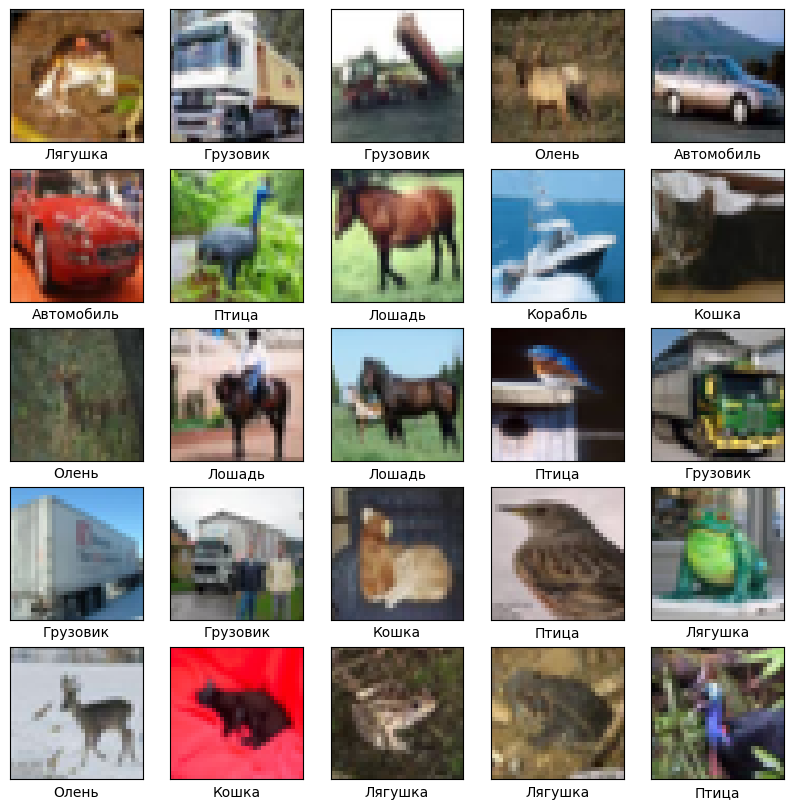

In [5]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [6]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

model.summary()

/home/ubuntu/ws/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1774180925.491924   23383 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model.fit(
    train_images, train_labels,
    epochs=15,                    # можно увеличить до 20–30
    batch_size=64,
    validation_data=(test_images, test_labels),
    verbose=1
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - accuracy: 0.4318 - loss: 1.5553 - val_accuracy: 0.5263 - val_loss: 1.3213
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.5700 - loss: 1.2058 - val_accuracy: 0.5882 - val_loss: 1.1660
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.6253 - loss: 1.0649 - val_accuracy: 0.6321 - val_loss: 1.0566
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.6607 - loss: 0.9759 - val_accuracy: 0.6674 - val_loss: 0.9567
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.6842 - loss: 0.9060 - val_accuracy: 0.6647 - val_loss: 0.9562
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - accuracy: 0.7035 - loss: 0.8469 - val_accuracy: 0.6739 - val_loss: 0.9330
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.7193 - loss: 0.8030 - val_accuracy: 0.6943 - val_loss: 0.8810
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.7335 - loss: 0.7656 - 

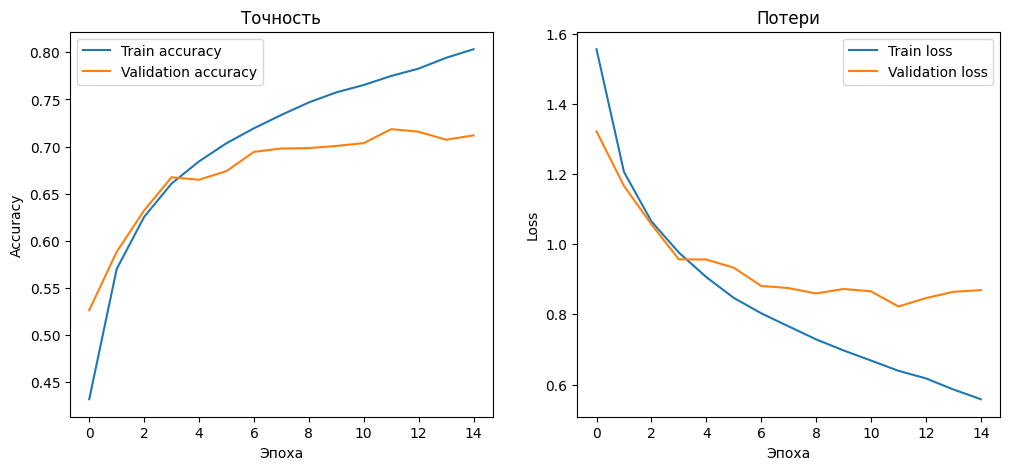

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Точность')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Потери')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [9]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nТочность на тестовых данных: {test_acc*100:.2f}%")

313/313 - 6s - 18ms/step - accuracy: 0.7118 - loss: 0.8689

Точность на тестовых данных: 71.18%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


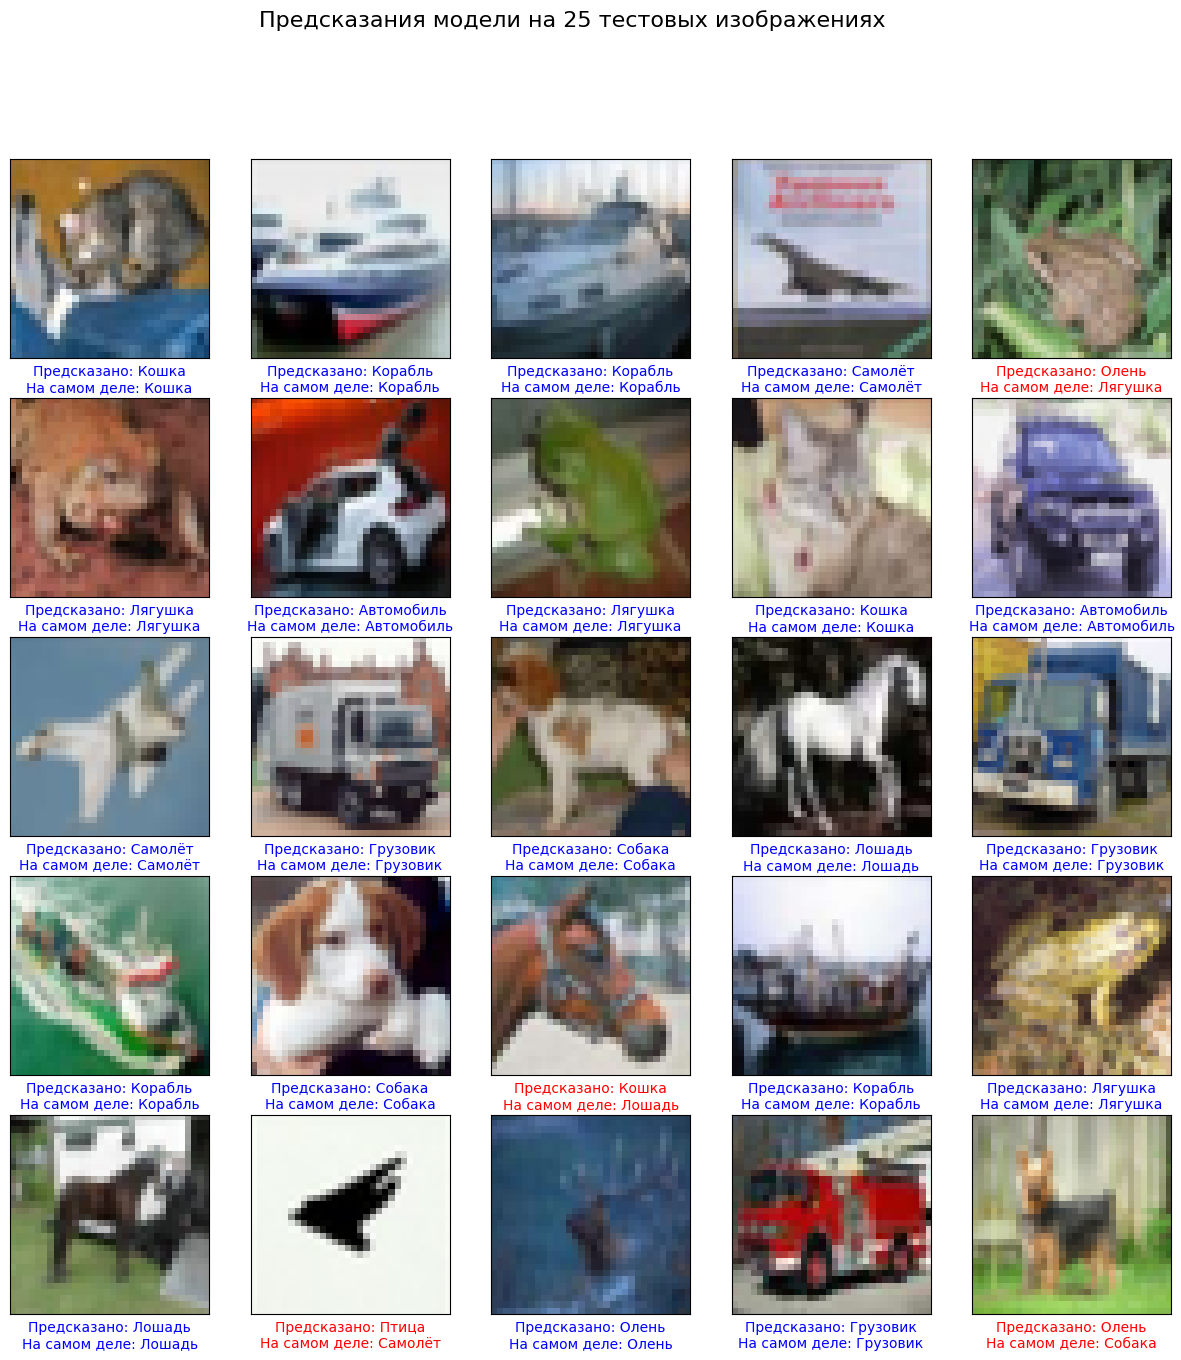

In [10]:
predictions = model.predict(test_images[:25])
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(15, 15))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_images[i])
    
    true_label = class_names[test_labels[i][0]]
    pred_label = class_names[predicted_labels[i]]
    color = 'blue' if true_label == pred_label else 'red'
    
    plt.xlabel(f"Предсказано: {pred_label}\nНа самом деле: {true_label}", color=color)
plt.suptitle("Предсказания модели на 25 тестовых изображениях", fontsize=16)
plt.show()